In [1]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import pickle
from sklearn.metrics import brier_score_loss, make_scorer, log_loss
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso, LogisticRegression
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
import shap

In [2]:
df = pd.read_csv("../Data/cleanedHealthData.csv")

In [3]:
## Establish weights for target variable
healthy_weight = df['target'].value_counts(normalize=True)['healthy']
diseased_weight = df['target'].value_counts(normalize=True)['diseased']

In [4]:
## Separate all the columns
numerical_cols = df.select_dtypes(include=['number']).columns
# numerical_cols = [col for col in numerical_cols if col != 'target']

categorical_cols = list(df.select_dtypes(exclude=['number']).columns)
categorical_cols = [col for col in categorical_cols if col != 'target']


In [5]:
## Convert object columns to categorical
obj_cols = df.select_dtypes(include=["object"]).columns
df[obj_cols] = df[obj_cols].astype("category")

In [6]:
## Set target as 1|0

df['target'] = df['target'].replace({'healthy': 0, 'diseased': 1})

y = df['target']
X = df.drop(columns='target')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

C:\Users\admin\AppData\Local\Temp\ipykernel_49600\3429725909.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['target'] = df['target'].replace({'healthy': 0, 'diseased': 1})
C:\Users\admin\AppData\Local\Temp\ipykernel_49600\3429725909.py:3: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df['target'] = df['target'].replace({'healthy': 0, 'diseased': 1})


In [7]:
## Setup Numerical and Categorical Cols Transformers (KNNImputer, Scaler and OHE)

num_transformer = Pipeline([
    ('imputer', KNNImputer(n_neighbors=3)), ## Reduce to 3 to save computation
    ('scaler', StandardScaler(with_mean=False)),
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('ohe', OneHotEncoder(drop = 'first', handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers = [
        ('num', num_transformer, numerical_cols),
        ('cat', cat_transformer, categorical_cols)
    ]
)

## For Random Forest only 
imp_transformer = Pipeline([
    ('imputer', KNNImputer(n_neighbors=3))
])

rf_preprocesser = ColumnTransformer(
    transformers = [
        ('num', imp_transformer, numerical_cols),
        ('cat', cat_transformer, categorical_cols)
    ] 
)

## Baseline Logistic Regression Model

In [8]:
## Logistic Regression pipeline (0.210771)

base_models = {
    'LogisticRegression': Pipeline([
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(random_state=42))
    ]),
}

results = []
for model, pipeline in tqdm(base_models.items(), desc="Training Models"):
    pipeline.fit(X_train, y_train)
    y_pred_prob = pipeline.predict_proba(X_test)[:, 1]   ## class 1 is diseased
    
    brier = brier_score_loss(y_test, y_pred_prob)
    logloss = log_loss(y_test, y_pred_prob)
    
    results.append({
        'Model': model,
        'Brier Score Loss': brier,
        'Log Loss': logloss
    })

results_df = pd.DataFrame(results).sort_values(by='Log Loss')
results_df

Training Models: 100%|██████████| 1/1 [03:09<00:00, 189.50s/it]


,Model,Brier Score Loss,Log Loss
0,LogisticRegression,0.210762,0.612561


In [9]:
def get_feature_names(preprocessor, numeric_cols, categorical_cols):
    feature_names = []

    if 'num' in preprocessor.named_transformers_:
        feature_names.extend(numeric_cols)

    if 'cat' in preprocessor.named_transformers_:
        ohe = preprocessor.named_transformers_['cat'].named_steps['ohe']
        ohe_names = ohe.get_feature_names_out(categorical_cols)
        feature_names.extend(ohe_names)

    return feature_names

## Use LASSO, Random Forest, KMeans for Feature Selection

In [10]:
## LASSO Feature Selection
fs_models = {
    'Lasso': Pipeline([
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(penalty='l1', solver='liblinear', random_state=42))
    ])
}

# results = []
for model, pipeline in tqdm(fs_models.items(), desc="Lasso Feature Selection"):
    pipeline.fit(X_train, y_train)
    y_pred_prob = pipeline.predict_proba(X_test)[:, 1]   ## class 1 is diseased
    
    brier = brier_score_loss(y_test, y_pred_prob)
    logloss = log_loss(y_test, y_pred_prob)
    
    ## Get feature names (OHE produced more)
    pre = pipeline.named_steps['preprocessor']
    feature_names = get_feature_names(pre, numerical_cols, categorical_cols)
    
    lasso_importance = pd.Series(np.abs(pipeline['model'].coef_).flatten(), index=feature_names)
    lasso_features = set(lasso_importance[lasso_importance > 0].index)
    
    results.append({
        'Model': model,
        'Brier Score Loss': brier,
        'Log Loss': logloss
    })

results_df = pd.DataFrame(results).sort_values(by='Log Loss')
results_df


Lasso Feature Selection: 100%|██████████| 1/1 [03:17<00:00, 197.85s/it]


,Model,Brier Score Loss,Log Loss
0,LogisticRegression,0.210762,0.612561
1,Lasso,0.210762,0.612562


In [11]:
print(f"Lasso Feature Selection:\n{lasso_features}")

Lasso Feature Selection:
{'weight', 'mental_health_score', 'insulin', 'stress_level', 'occupation_Doctor', 'occupation_Engineer', 'income', 'cholesterol', 'daily_steps', 'age', 'smoking_level_Non-smoker', 'heart_rate', 'occupation_Teacher', 'healthcare_access_Poor', 'alcohol_consumption_Regularly', 'job_type_Office', 'work_hours', 'caffeine_intake_Moderate', 'family_history_Yes', 'glucose', 'occupation_Farmer', 'sleep_quality_Poor', 'water_intake', 'diet_type_Vegetarian', 'job_type_Labor', 'exercise_type_Mixed', 'education_level_High School', 'insurance_Yes', 'caffeine_intake_Missing', 'meals_per_day', 'bmi_corrected', 'sleep_hours', 'physical_activity', 'pet_owner_Yes', 'mental_health_support_Yes', 'job_type_Tech', 'diet_type_Omnivore', 'height', 'healthcare_access_Moderate', 'sunlight_exposure_Low', 'calorie_intake', 'smoking_level_Light', 'blood_pressure', 'daily_supplement_dosage', 'gender_Male', 'sugar_intake', 'diet_type_Vegan', 'job_type_Unemployed', 'alcohol_consumption_Occasio

In [12]:
## Random Forest Feature Selection
fs_models = {
    'RandomForest': Pipeline([
        ('preprocessor', rf_preprocesser),  ## No StandardScaler for RF
        ('model', RandomForestClassifier(random_state=42))
    ])
}

results = []
for model, pipeline in tqdm(fs_models.items(), desc="Random Forest Feature Selection"):
    pipeline.fit(X_train, y_train)
    y_pred_prob = pipeline.predict_proba(X_test)[:, 1]   ## class 1 is diseased
    
    brier = brier_score_loss(y_test, y_pred_prob)
    logloss = log_loss(y_test, y_pred_prob)
    
    ## Get feature names (OHE produced more)
    pre = pipeline.named_steps['preprocessor']
    feature_names = get_feature_names(pre, numerical_cols, categorical_cols)
    
    rf_importance = pd.Series(pipeline['model'].feature_importances_, index=feature_names)
    rf_features = set(rf_importance[rf_importance > rf_importance.mean()].index)
    
    results.append({
        'Model': model,
        'Brier Score Loss': brier,
        'Log Loss': logloss
    })

results_df = pd.DataFrame(results).sort_values(by='Log Loss')
results_df

Random Forest Feature Selection: 100%|██████████| 1/1 [03:44<00:00, 225.00s/it]


,Model,Brier Score Loss,Log Loss
0,RandomForest,0.21366,0.619371


In [13]:
rf_importance.sort_values(ascending=False)

insulin                     0.038739
heart_rate                  0.038703
waist_size                  0.038585
sugar_intake                0.038533
daily_steps                 0.038463
                              ...   
occupation_Farmer           0.004096
occupation_Doctor           0.004080
occupation_Engineer         0.003997
job_type_Office             0.003881
gene_marker_flag_Missing    0.003460
Length: 63, dtype: float64

In [14]:
print(f"Random Forest Feature Selection:\n{rf_features}")

Random Forest Feature Selection:
{'weight', 'mental_health_score', 'insulin', 'stress_level', 'income', 'cholesterol', 'daily_steps', 'age', 'heart_rate', 'work_hours', 'glucose', 'water_intake', 'bmi_corrected', 'sleep_hours', 'physical_activity', 'height', 'calorie_intake', 'blood_pressure', 'daily_supplement_dosage', 'sugar_intake', 'waist_size', 'screen_time'}


In [15]:
## XGB Feature Selection
fs_models = {
    'XGB': Pipeline([
        ('model', XGBClassifier(enable_categorical=True, random_state=42))   ## No scaling needed
    ])
}

results = []
for model, pipeline in tqdm(fs_models.items(), desc="XGB Feature Selection"):
    pipeline.fit(X_train, y_train)
    y_pred_prob = pipeline.predict_proba(X_test)[:, 1]   ## class 1 is diseased
    
    brier = brier_score_loss(y_test, y_pred_prob)
    logloss = log_loss(y_test, y_pred_prob)
    
    explainer = shap.TreeExplainer(pipeline['model'])
    shap_values = explainer.shap_values(X_train)
   
    
    shap_importance = pd.Series(np.abs(shap_values).mean(0), index=X.columns)
    xgb_feature_names = set(shap_importance.nlargest(30).index)

    results.append({
        'Model': model,
        'Brier Score Loss': brier,
        'Log Loss': logloss
    })

results_df = pd.DataFrame(results).sort_values(by='Log Loss')
results_df

XGB Feature Selection: 100%|██████████| 1/1 [00:06<00:00,  6.00s/it]


,Model,Brier Score Loss,Log Loss
0,XGB,0.218409,0.632276


In [16]:
print(f"XGB Feature Selection:\n{xgb_feature_names}")

XGB Feature Selection:
{'weight', 'mental_health_score', 'insulin', 'stress_level', 'income', 'daily_steps', 'cholesterol', 'age', 'healthcare_access', 'heart_rate', 'work_hours', 'glucose', 'water_intake', 'diet_type', 'sleep_hours', 'bmi_corrected', 'physical_activity', 'sleep_quality', 'height', 'calorie_intake', 'blood_pressure', 'device_usage', 'daily_supplement_dosage', 'sugar_intake', 'exercise_type', 'education_level', 'waist_size', 'screen_time', 'job_type', 'occupation'}


In [22]:
## Filtered out 22 features (length of rf_features)

selected_features = (
    lasso_features & rf_features |
    lasso_features & xgb_feature_names |
    rf_features & xgb_feature_names
)

selected_features = list(selected_features)
print(len(selected_features))
print("\n Final Selected Features:\n", selected_features)

22

 Final Selected Features:
 ['weight', 'mental_health_score', 'insulin', 'stress_level', 'income', 'cholesterol', 'daily_steps', 'age', 'heart_rate', 'work_hours', 'glucose', 'water_intake', 'bmi_corrected', 'sleep_hours', 'physical_activity', 'height', 'calorie_intake', 'blood_pressure', 'daily_supplement_dosage', 'sugar_intake', 'waist_size', 'screen_time']


## Baseline Pipeline of all Models on Full Data

In [ ]:
models = {
    'LogisticRegression': Pipeline([
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(random_state=42))
    ]),
    'RandomForest': Pipeline([
        ('preprocessor', rf_preprocesser),
        ('model', RandomForestClassifier(random_state=42))
    ]),
    'GradientBoosting': Pipeline([
        ('preprocessor', preprocessor),
        ('model', GradientBoostingClassifier(random_state=42))
    ]),
    'DecisionTree': Pipeline([
        ('preprocessor', preprocessor),
        ('model', DecisionTreeClassifier(random_state=42))
    ]),
    'KNN': Pipeline([
        ('preprocessor', preprocessor),
        ('model', KNeighborsClassifier(n_neighbors=5))
    ]),
    'XGBoost': Pipeline([
        ('model', XGBClassifier(enable_categorical=True, random_state=42))
    ])
}

In [19]:
results = []

for model, pipeline in tqdm(models.items(), desc="Training Baseline Models Full Data"):
    pipeline.fit(X_train, y_train)
    y_pred_prob = pipeline.predict_proba(X_test)[:, 1]   ## class 1 is diseased
    
    brier = brier_score_loss(y_test, y_pred_prob)
    logloss = log_loss(y_test, y_pred_prob)
    
    results.append({
        'Model': model,
        'Brier Score Loss': brier,
        'Log Loss': logloss
    })

baseline_results_df = pd.DataFrame(results).sort_values(by='Log Loss')
# results_df.to_csv('../Data/preliminaryResults.csv', index=False)
# results_df

Training Baseline Models Full Data: 100%|██████████| 6/6 [17:11<00:00, 171.89s/it]


In [20]:
baseline_results_df

,Model,Brier Score Loss,Log Loss
0,LogisticRegression,0.210762,0.612561
2,GradientBoosting,0.210801,0.612651
1,RandomForest,0.213660,0.619371
5,XGBoost,0.218409,0.632276
4,KNN,0.251964,2.432118
3,DecisionTree,0.433250,15.615913


## Use Logistic Regression, Random Forest, Boosting Models to Evaluate Selection

In [89]:
## Filter dataset for selected features
# X_train = X_train[list(selected_features)]
# X_test = X_test[list(selected_features)]

selected_categorical_cols = [feature for feature in categorical_cols if feature in selected_features]
selected_numerical_cols = [feature for feature in numerical_cols if feature in selected_features]

## Adjust Preprocessor and Pipeline based on limited features

sel_preprocessor = ColumnTransformer(
    transformers = [
        ('num', num_transformer, selected_numerical_cols),
        ('cat', cat_transformer, selected_categorical_cols),
    ], remainder='drop'
)

sel_rf_preprocesser = ColumnTransformer(
    transformers = [
        ('num', imp_transformer, selected_numerical_cols),
        ('cat', cat_transformer, selected_categorical_cols),
    ], remainder='drop'
)

sel_models = {
    'LogisticRegression': Pipeline([
        ('preprocessor', sel_preprocessor),
        ('model', LogisticRegression(random_state=42))
    ]),
    'RandomForest': Pipeline([
        ('preprocessor', sel_rf_preprocesser),
        ('model', RandomForestClassifier(random_state=42))
    ]),
    'GradientBoosting': Pipeline([
        ('preprocessor', sel_preprocessor),
        ('model', GradientBoostingClassifier(random_state=42))
    ]),
    'DecisionTree': Pipeline([
        ('preprocessor', sel_preprocessor),
        ('model', DecisionTreeClassifier(random_state=42))
    ]),
    'KNN': Pipeline([
        ('preprocessor', sel_preprocessor),
        ('model', KNeighborsClassifier(n_neighbors=5))
    ]),
    'XGBoost': Pipeline([
        ('model', XGBClassifier(enable_categorical=True, random_state=42))
    ])
}


In [90]:
results = []

for model, pipeline in tqdm(sel_models.items(), desc="Training Baseline Models Selected Data"):
    pipeline.fit(X_train, y_train)
    y_pred_prob = pipeline.predict_proba(X_test)[:, 1]   ## class 1 is diseased
    
    brier = brier_score_loss(y_test, y_pred_prob)
    logloss = log_loss(y_test, y_pred_prob)
    
    results.append({
        'Model': model,
        'Brier Score Loss': brier,
        'Log Loss': logloss
    })

selected_results_df = pd.DataFrame(results).sort_values(by='Log Loss')
# results_df.to_csv('../Data/preliminaryResults.csv', index=False)
# results_df

Training Baseline Models Selected Data: 100%|██████████| 6/6 [16:48<00:00, 168.14s/it]


In [91]:
baseline_results_df

,Model,Brier Score Loss,Log Loss
0,LogisticRegression,0.210762,0.612561
2,GradientBoosting,0.210801,0.612651
1,RandomForest,0.213660,0.619371
5,XGBoost,0.218409,0.632276
4,KNN,0.251964,2.432118
3,DecisionTree,0.433250,15.615913


In [92]:
selected_results_df

,Model,Brier Score Loss,Log Loss
0,LogisticRegression,0.210602,0.612176
2,GradientBoosting,0.210727,0.612485
1,RandomForest,0.213666,0.619433
5,XGBoost,0.218409,0.632276
4,KNN,0.251318,2.494181
3,DecisionTree,0.424650,15.305937


## Hyperparameter Tuning

In [ ]:
## Set parameters for each model
neg_class = y.value_counts()[0]
pos_class = y.value_counts()[1]
ratio = neg_class / pos_class

param_grids = {
    "GradientBoosting": {
        "model__n_estimators": [100, 200, 300],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__max_depth": [3, 4, 5],
        "model__subsample": [0.6, 0.8, 1.0],
    },
    "LogisticRegression": {
        "model__C": np.logspace(-3, 3, 10),
        "model__solver": ["liblinear", "saga"],
        "model__penalty": ["l2", "l1"],
        "model__class_weight": ['balanced', None]
    },
    "RandomForest": {
        "model__n_estimators": [100, 200, 300, 500],
        "model__max_depth": [None, 5, 10, 20, 30],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
        "model__class_weight": ['balanced', None]

    },
    "KNN": {
        "model__n_neighbors": [3, 5, 7, 9, 11, 13, 15],
        "model__weights": ["uniform", "distance"],
        "model__metric": ["euclidean", "manhattan"],
    },
    "DecisionTree": {
        "model__max_depth": [None, 5, 10, 20],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
        "model__criterion": ["gini", "entropy"],
        "model__class_weight": ['balanced', None]
    },
    'XGBoost': {
        "model__n_estimators": [200, 400, 800],
        "model__learning_rate": [0.001, 0.05, 0.1],
        "model__max_depth": [2, 3, 4, 5, 6],
        "model__subsample": [0.6, 0.8, 1.0],
        "model__colsample_bytree": [0.6, 0.8, 1.0],
        "model__scale_pos_weight": [1, ratio*0.5, ratio, ratio*2]  ## Negative Class / Positive Class
    }
    
}

In [94]:
log_loss_scorer = make_scorer(log_loss, response_method='predict_proba', greater_is_better=False, labels=[0,1])
brier_scorer = make_scorer(brier_score_loss, response_method='predict_proba', greater_is_better=False, labels=[0,1])

scoring = {
    "log_loss": log_loss_scorer,
    "brier": brier_scorer
}

In [103]:
## Features that were not selected
features_notUsed = list(set(X.columns).difference(set(selected_features)))
sorted(features_notUsed)

['alcohol_consumption',
 'caffeine_intake',
 'device_usage',
 'diet_type',
 'education_level',
 'exercise_type',
 'family_history',
 'gender',
 'gene_marker_flag',
 'healthcare_access',
 'insurance',
 'job_type',
 'meals_per_day',
 'mental_health_support',
 'occupation',
 'pet_owner',
 'sleep_quality',
 'smoking_level',
 'sunlight_exposure']

In [96]:
## Perform Randomized Search on selected features
best_models = {}

## Need to use selected features models pipeline
for name, pipeline in sel_models.items():
    print(f"\n Running RandomizedSearchCV for {name}...")
    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_grids[name],
        n_iter=10,              ## try 10 random combinations
        scoring=scoring,
        refit='log_loss', 
        cv=3,                   ## reduce to increase computation speed
        verbose=2,
        random_state=42,
        error_score='raise',
        n_jobs=4,               ## use 4 CPU cores
        pre_dispatch="2*n_jobs"
    )
    search.fit(X_train, y_train)
    best_models[name] = search.best_estimator_
    
    print(f"Best params for {name}: {search.best_params_}")
    print(f"Best CV log loss: {-search.best_score_:.4f}")

# Evaluate best models on test set
print("\n Test Log Loss:")
models_dict = {}
for name, model in best_models.items():
    y_pred_proba = model.predict_proba(X_test)[:, 1]   ## class 1 is diseased
    ll = log_loss(y_test, y_pred_proba)
    models_dict[name]= ll
    print(f"{name}: {ll:.4f}")
    
    
## Pickle best model
with open("selectedFeatures_best_model.pkl", "wb") as f:
    pickle.dump(best_models[name], f)

res_df = pd.DataFrame.from_dict(models_dict, orient='index').reset_index()
res_df.columns = ['Model', 'Test Log Loss']
res_df.to_csv("../Data/tunedFSAllModels_new.csv", index=False)


 Running RandomizedSearchCV for LogisticRegression...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best params for LogisticRegression: {'model__solver': 'liblinear', 'model__penalty': 'l1', 'model__class_weight': None, 'model__C': np.float64(0.021544346900318832)}
Best CV log loss: 0.6097

 Running RandomizedSearchCV for RandomForest...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best params for RandomForest: {'model__n_estimators': 100, 'model__min_samples_split': 10, 'model__min_samples_leaf': 4, 'model__max_depth': 5, 'model__class_weight': None}
Best CV log loss: 0.6097

 Running RandomizedSearchCV for GradientBoosting...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best params for GradientBoosting: {'model__subsample': 0.6, 'model__n_estimators': 100, 'model__max_depth': 3, 'model__learning_rate': 0.01}
Best CV log loss: 0.6096

 Running RandomizedSearchCV for DecisionTree...
Fitting 3 folds for each of 10 candidates, totalling 30 

In [97]:
## Perform Randomized Search on all features
best_models = {}

for name, pipeline in models.items():
    print(f"\n Running RandomizedSearchCV for {name}...")
    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_grids[name],
        n_iter=10,              ## try 10 random combinations
        scoring=scoring,
        refit='log_loss',  
        cv=3,                   ## reduce to increase computation speed
        verbose=2,
        random_state=42,
        error_score='raise',
        n_jobs=4,               ## use 4 CPU cores
        pre_dispatch="2*n_jobs"              
    )
    search.fit(X_train, y_train)
    best_models[name] = search.best_estimator_
    
    print(f"Best params for {name}: {search.best_params_}")
    print(f"Best CV log loss: {-search.best_score_:.4f}")

models_dict = {}
# Evaluate best models on test set
print("\n Test Log Loss:")
for name, model in best_models.items():
    y_pred_proba = model.predict_proba(X_test)[:, 1]   ## class 1 is diseased
    ll = log_loss(y_test, y_pred_proba)
    models_dict[name]= ll
    print(f"{name}: {ll:.4f}")

## Pickle best model
with open("allFeatures_best_model.pkl", "wb") as f:
    pickle.dump(best_models[name], f)

res_df = pd.DataFrame.from_dict(models_dict, orient='index').reset_index()
res_df.columns = ['Model', 'Test Log Loss']
res_df = res_df.sort_values(by='Test Log Loss', ascending=True)
res_df.to_csv("../Data/tunedFullAllModels_new.csv", index=False)


 Running RandomizedSearchCV for LogisticRegression...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best params for LogisticRegression: {'model__solver': 'liblinear', 'model__penalty': 'l1', 'model__class_weight': None, 'model__C': np.float64(0.021544346900318832)}
Best CV log loss: 0.6097

 Running RandomizedSearchCV for RandomForest...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best params for RandomForest: {'model__n_estimators': 100, 'model__min_samples_split': 10, 'model__min_samples_leaf': 1, 'model__max_depth': 5, 'model__class_weight': None}
Best CV log loss: 0.6096

 Running RandomizedSearchCV for GradientBoosting...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best params for GradientBoosting: {'model__subsample': 0.6, 'model__n_estimators': 100, 'model__max_depth': 3, 'model__learning_rate': 0.01}
Best CV log loss: 0.6096

 Running RandomizedSearchCV for DecisionTree...
Fitting 3 folds for each of 10 candidates, totalling 30 

## Distribution of Predicted Probabilities Risk Scores

In [120]:
probs = fs_loaded_model.predict_proba(X_test)[:, 1]
probs.min(), probs.max(), probs.std()

(np.float32(0.2686458), np.float32(0.34212354), np.float32(0.0055538663))

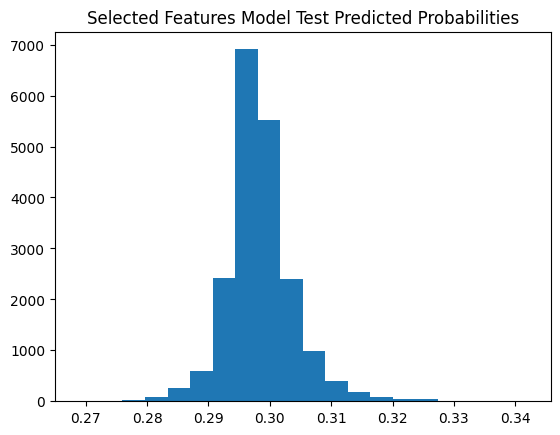

In [121]:
plt.hist(probs, bins=20)
plt.title("Selected Features Model Test Predicted Probabilities")
plt.show()

In [118]:
all_probs = all_loaded_model.predict_proba(X_test)[:, 1]
all_probs.min(), all_probs.max(), all_probs.std()

(np.float32(0.2686458), np.float32(0.34212354), np.float32(0.0055538663))

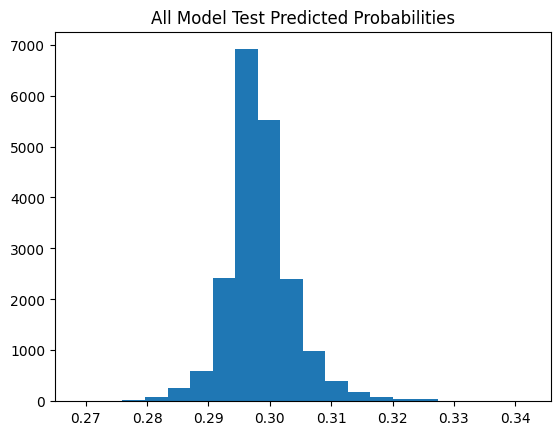

In [119]:
plt.hist(all_probs, bins=20)
plt.title("All Model Test Predicted Probabilities")
plt.show()